---
title: "Homework 3"
format:
    html:
        code-fold: true

    pdf:
        toc: false
        number-sections: true
        colorlinks: true
        code-block-bg: "#f5f5f5"

jupyter: python3
keep-ipynb: true
syntax-highlighting: github

---

### Part 1

Sample ellipse:

In [ ]:
## sampling an elipse
import plotly.io as pio
pio.renderers.default = "notebook"
import warnings
warnings.filterwarnings("ignore")

import ellipse
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
e = ellipse.get_ellipse(a = 12, b = 6, row = 48, col = 35, theta = 0)


# ellipse.get_ellipse(a = 12, b = 6, row = 48, col = 35, theta = 0).dtype

In [2]:
## gernerate data
N = 1000
rng = np.random.default_rng()

data = np.zeros((N, 64, 64))
rows = rng.uniform(16, 48, N)
cols = rng.uniform(16, 48, N)

for i in range(N):
    e = ellipse.get_ellipse(a = 12, b = 6, row = rows[i], col = cols[i], theta = 0)

    data[i] = e

#### A. Dimensionality of Raw Data
Since the images of the elipses are 64 pixels by 64 pixels, the dimensionality of our data is $64 \times 64 = 4,096$.

#### B. Dimension of Data Manifold
I expect the intrinsic dimensionality of the data to be 2, since the only meaningful variation in our dataset is the x and y coordinates of the center of our elipse. Even though our data lives in a 4,096-dimensional space, the difference between our data points are completely described by two coordinates.

#### C. PCA

In [3]:
from sklearn.decomposition import PCA
pca = PCA()
data_flattened = data.reshape(N, 64 * 64)
print(data_flattened.shape)
pca.fit(data_flattened);

(1000, 4096)


In [4]:
n_components = pca.singular_values_.size
near_zero = np.sum(np.isclose(pca.singular_values_, 0))

print(f"Number of non-zero pricipal components: {n_components - near_zero}")

# pca.singular_values_

Number of non-zero pricipal components: 999


I found that 999 of the eigenvalues were non-zero noise. It seems like one axis of variability is being lost to the mean centering of the data.

#### D. Plotting PCA

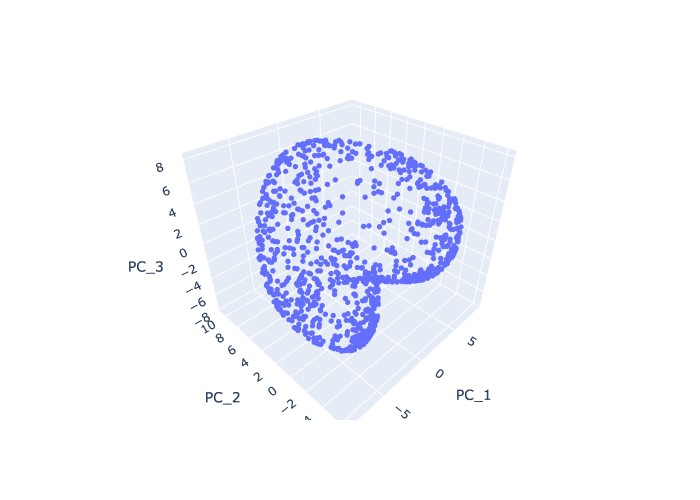

In [5]:
import plotly.express as px
import pandas as pd
PCA_projection = pca.components_[:3] @ data_flattened.T

df = pd.DataFrame(PCA_projection.T, columns=["PC_1", "PC_2", "PC_3"])
df["rows"] = rows
df["cols"] = cols

fig = px.scatter_3d(df, x="PC_1", y="PC_2", z="PC_3")
fig.update_traces(marker=dict(size=3))  # smaller dots
fig.update_layout(scene_camera=dict(eye=dict(x=-1.25, y=-1.25, z=1.25)))
fig.show()

Wow, this shape is fascinating! I absolutely didn't excpet the data to look like this. This shape looks like a warped sheet of paper (lending support to my hypothesis that the intrisic dimensionality of the data is 2) which comes together to 4 "corners". I wonder if the data points here represent the elipses with centers at the "corners" at the possible combinations of x and y values. Let's find out. 


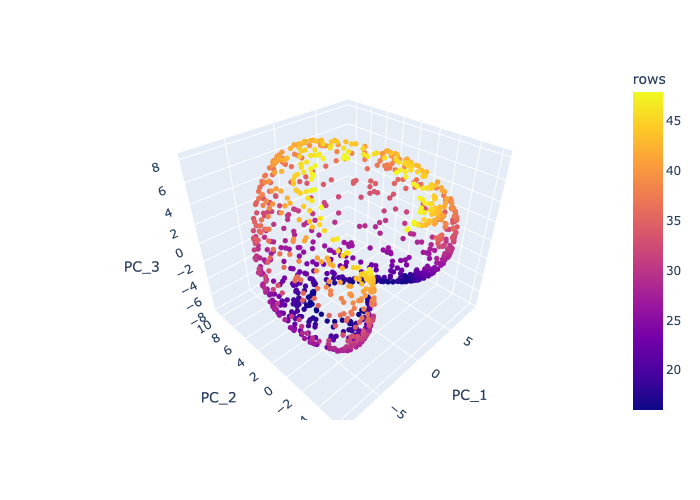

In [6]:
fig_1 = px.scatter_3d(df, x="PC_1", y="PC_2", z="PC_3", color="rows")
fig_1.update_traces(marker=dict(size=3))  # smaller dots
fig_1.update_layout(scene_camera=dict(eye=dict(x=-1.25, y=-1.25, z=1.25)))
fig_1.show()

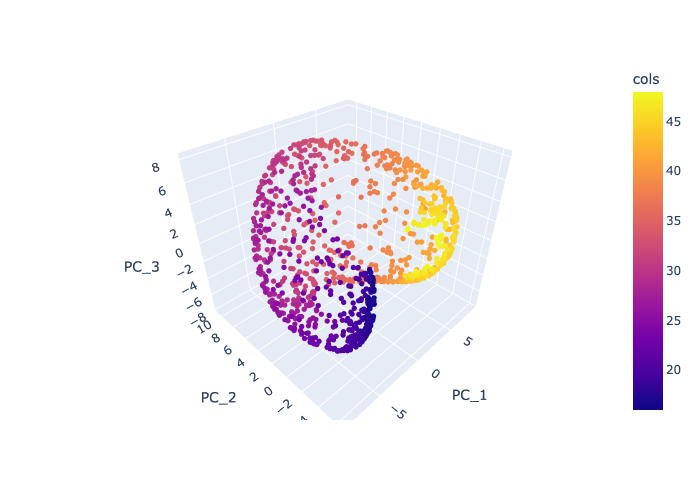

In [7]:
fig_2 = px.scatter_3d(df, x="PC_1", y="PC_2", z="PC_3", color="cols")
fig_2.update_traces(marker=dict(size=3))  # smaller dots
fig_2.update_layout(scene_camera=dict(eye=dict(x=-1.25, y=-1.25, z=1.25)))
fig_2.show()

I was right! The "corners" correspond to the "corners" of the $[16, 48] \times [16,48]$ set of possible x-y center coordinates for the elipses.

I was expecting a 2d shape, but I guess I pictured something less curved.

### Part 2

#### A. Pre-IsoMap Predictions

Before computing an IsoMap, I don't think the IsoMap will embedd the data isometrically into Euclidan space. This is because the shape that arises out of the above PCA scatterplot is clearly not flat. It seems to be positively curved. I think IsoMap will still try to embed our data in a 2d space, but it will to do so isometrically.

#### B. IsoMap

In [8]:
from sklearn.manifold import Isomap

embedding = Isomap(n_components = 3)
embedding.fit(X = data_flattened)

## computing the Gram Matrix 
D = embedding.dist_matrix_
H = np.identity(N) - 1/N * np.ones((N,N))

B = -1/2 * H @ D @ H

# Eigen Analysis
singular_values, vecs = np.linalg.eig(B)

singular_values = np.sort(singular_values)[::-1]


Negative = np.sum((singular_values < 0))
print(f"Number of non-negative eigenvalues: {len(singular_values) - Negative}")
print(f"Number of negative eigenvalues: {Negative}")

Number of non-negative eigenvalues: 779
Number of negative eigenvalues: 221


Our data isn't flat, since it has a 223 negative eigenvalues and only 777 which are positive. I think IsoMap will still try do a decent job embedding the data in two dimensions.

#### C. IsoMap Visualization

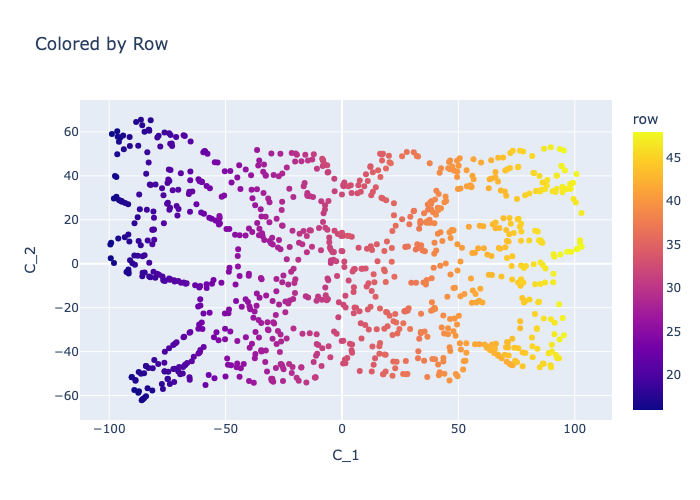

In [9]:
from plotly.subplots import make_subplots

embedding_vector_df = pd.DataFrame(np.stack((embedding.embedding_[:,0].T, embedding.embedding_[:,1].T, embedding.embedding_[:,2], rows, cols)).T, columns=["C_1", "C_2", "C_3", "col", "row"])

px.scatter(
    embedding_vector_df,
    x = "C_1",
    y = "C_2",
    color="row",
    title="Colored by Row",
)

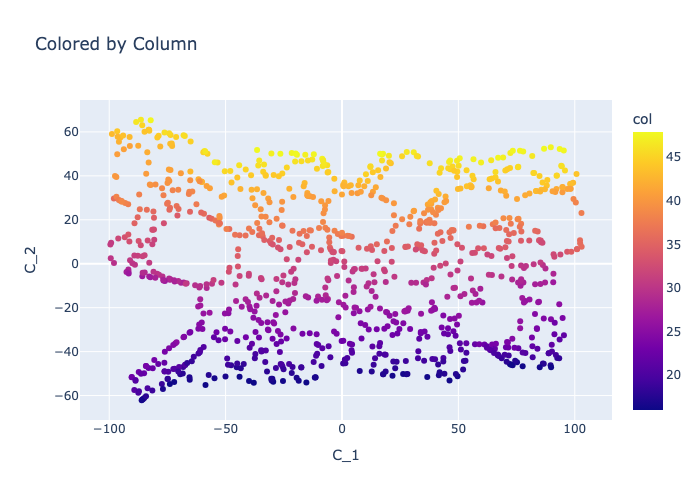

In [10]:
px.scatter(
    embedding_vector_df,
    x = "C_1",
    y = "C_2",
    color="col",
    title="Colored by Column",
)

Wow, that looks really really good!

#### D. 3D IsoMap Visualization

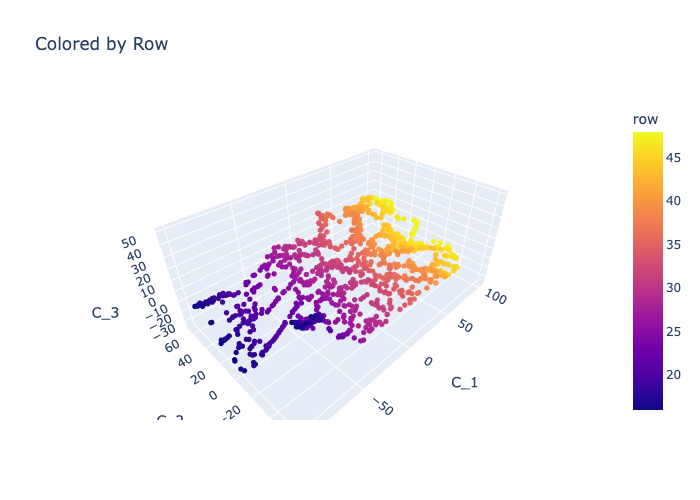

In [11]:
fig = px.scatter_3d(
    embedding_vector_df,
    x = "C_1",
    y = "C_2",
    z = "C_3",
    color="row",
    title="Colored by Row",
)
fig.update_traces(marker=dict(size=3))  # smaller dots
fig.update_layout(scene_camera=dict(eye=dict(x=-1.25, y=-1.25, z=1.25)))

Wow, this is definetely a curved shape. The plot changes with each run. But each new shape is pretty curved. I was right that the manifold would be curved, but decently embeddable in 2 dimensions.

### Part 3

In [12]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"


import numpy as np
import torch

from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
import torchvision.utils as vutils
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import ellipse

# This line sets the device to either a gpu or cpu
if torch.cuda.is_available():
    device = "cuda:0"
elif torch.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Device: {device}")

class ConvolutionalAutoencoder(nn.Module):
    def __init__(self, num_channels, out_size):
        super(ConvolutionalAutoencoder, self).__init__()
        self.econv1 = nn.Conv2d(num_channels, 32, kernel_size = 5, bias = False)
        self.ebatch1 = nn.BatchNorm2d(32, track_running_stats=False)
        self.econv2 = nn.Conv2d(32, 8, kernel_size = 5, bias = False)
        self.ebatch2 = nn.BatchNorm2d(8, track_running_stats=False)
        self.econv3 = nn.Conv2d(8, out_size, kernel_size = 56, bias = True)

        self.dconv1 = nn.ConvTranspose2d(out_size, 8, kernel_size = 56, bias = True)
        self.dbatch1 = nn.BatchNorm2d(8, track_running_stats=False)
        self.dconv2 = nn.ConvTranspose2d(8, 32, kernel_size = 5, bias = False)
        self.dbatch2 = nn.BatchNorm2d(32, track_running_stats=False)
        self.dconv3 = nn.ConvTranspose2d(32, num_channels, kernel_size = 5, bias = False)

    def encoder(self, x):
        y1 = F.elu(self.ebatch1(self.econv1(x)))
        y2 = F.elu(self.ebatch2(self.econv2(y1)))
        z = self.econv3(y2)
        return z

    def decoder(self, z):
        y1 = F.elu(self.dbatch1(self.dconv1(z)))
        y2 = F.elu(self.dbatch2(self.dconv2(y1)))
        x = torch.sigmoid(self.dconv3(y2))
        return x
     
    def forward(self, x):
        z = self.encoder(x)
        y = self.decoder(z)
        return y

## DEBUG: MAKING THE AUTOENCODER MORE ACCURATE

def train(autoencoder, data_loader, num_epochs = 50, learn_rate = 0.1, weight_decay = 0.0, verbose = True):
    optimizer = torch.optim.SGD(autoencoder.parameters(), lr = learn_rate, weight_decay = weight_decay)
    mse_loss = nn.MSELoss()

    for epoch in range(num_epochs):
        tot_loss = 0
        for i, (x, label) in enumerate(data_loader):
            x = x.to(device)
            y = autoencoder(x)

            loss = mse_loss(x, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            tot_loss = tot_loss + loss.data.cpu().numpy()
        if verbose:
            print(epoch, ": Loss =", tot_loss)
    print(f"Final Loss: {tot_loss}")

    return autoencoder


N = 1000           # training data size
batch_size = 100   # set a batch size that works for you (might just use N)
num_channels = 1   # set this to 1 for ellipse (grayscale) and 3 for teapot (colbor)

# Replace the line below with your generated ellipse images training dataset
rng = np.random.default_rng()

data = np.zeros((N, 64, 64))
rows = rng.uniform(16, 48, N)
cols = rng.uniform(16, 48, N)

for i in range(N):
    e = ellipse.get_ellipse(a = 12, b = 6, row = rows[i], col = cols[i], theta = 0)

    data[i] = e

X = torch.Tensor(data).unsqueeze(1)

# These are dummy labels needed to create pytorch TensorDataset
y = torch.zeros(N)

train_data = TensorDataset(X, y)
train_loader = DataLoader(train_data, batch_size = batch_size, shuffle = True)

Device: mps


In [13]:
latent_dim = 2 # set your latent dimension here

convAE2 = ConvolutionalAutoencoder(num_channels, latent_dim)

try:
    convAE2.load_state_dict(torch.load("convAE2.pth", map_location=device))
    convAE2.to(device)
    print("Loaded checkpoint")
except:
    print("No checkpoint found, training from scratch")
    convAE2 = train(convAE2.to(device), train_loader)
    torch.save(convAE2.state_dict(), "convAE2.pth")

Loaded checkpoint


#### A. Evaluation of Reconstruction

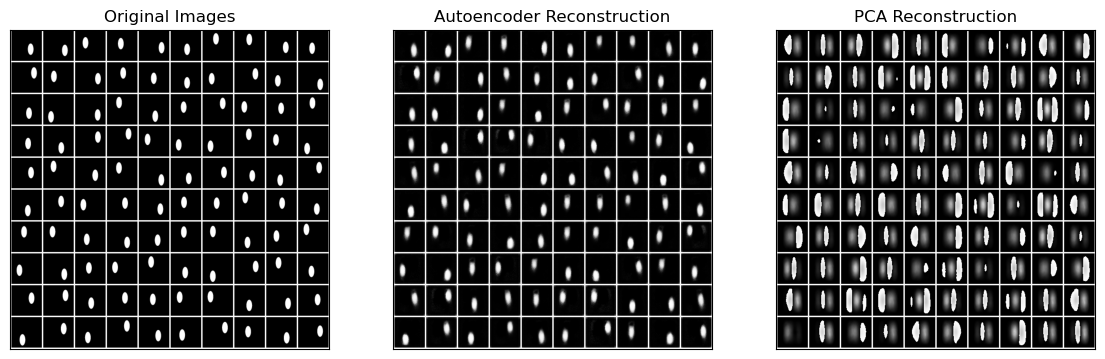

In [14]:
# Making testing data
rows_test, cols_test = rng.uniform(16, 48, 100), rng.uniform(16, 48, 100)

test = np.zeros((100, 64, 64))

for id, (r, c) in enumerate(zip(rows_test, cols_test)):
    e = ellipse.get_ellipse(a = 12, b = 6, row = r, col = c, theta = 0)
    test[id] = torch.Tensor(e)

test_tensor = torch.from_numpy(test).float().to(device).unsqueeze(1)

# Reconstructing with the auto encoder
with torch.no_grad():
    y = convAE2.forward(test_tensor.to(device))

# Reconstruct with PCA
mean = pca.mean_
centered_flat = test.reshape(100, 64 * 64) - mean
PCS = pca.components_[:latent_dim]
pca_reconstruction = (PCS @ centered_flat.T).T @ PCS + mean
pca_reconstruction_t = torch.from_numpy(
        pca_reconstruction.reshape(100, 64, 64)
    ).unsqueeze(1)

# plotting grids
def show(imgs, titles = None): ## from pytroch tutorial
    if not isinstance(imgs, list):
        imgs = [imgs]
    fig, axs = plt.subplots(ncols=len(imgs), squeeze=False, figsize = (14, 7))
    for i, img in enumerate(imgs):
        img = img.detach().cpu()
        img = transforms.functional.to_pil_image(img)
        axs[0, i].imshow(np.asarray(img))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])
        if titles:
            axs[0, i].set_title(titles[i])
grid_ae = vutils.make_grid(y, nrow = 10, pad_value = 1, padding=3)
grid_t =  vutils.make_grid(test_tensor, nrow = 10, pad_value = 1, padding=3)
grid_pca = vutils.make_grid(
    pca_reconstruction_t,
    nrow = 10, 
    pad_value = 1, 
    padding=3
    )

show([grid_t, grid_ae, grid_pca], titles = ["Original Images", "Autoencoder Reconstruction", "PCA Reconstruction"])

The autoencoder outshines the PCA reconstruction. I lowerd  the learning rate and trained for more epochs, which significantly improved its performance. The PCA does a terrible job. The two parameters seem to correspond to the elipse being in the left or right hemisphere and how much of the elipse is in the center of the data.

#### B. Increasing Latent Dim

In [15]:
# convAE16 = ConvolutionalAutoencoder(num_channels, latent_dim)

# convAE16.load_state_dict(torch.load("convAE16.pth", map_location=device))
# print("Loaded checkpoint")
# convAE16.to(device)

In [16]:
latent_dim = 16 # set your latent dimension here

convAE16 = ConvolutionalAutoencoder(num_channels, latent_dim)


try:
    convAE16.load_state_dict(torch.load("convAE16.pth", map_location=device))
    print("Loaded checkpoint")
    convAE16.to(device)

except:
    print("No checkpoint found, training from scratch")
    convAE16 = train(convAE16.to(device), train_loader)
    torch.save(convAE16.state_dict(), "convAE16.pth")

Loaded checkpoint


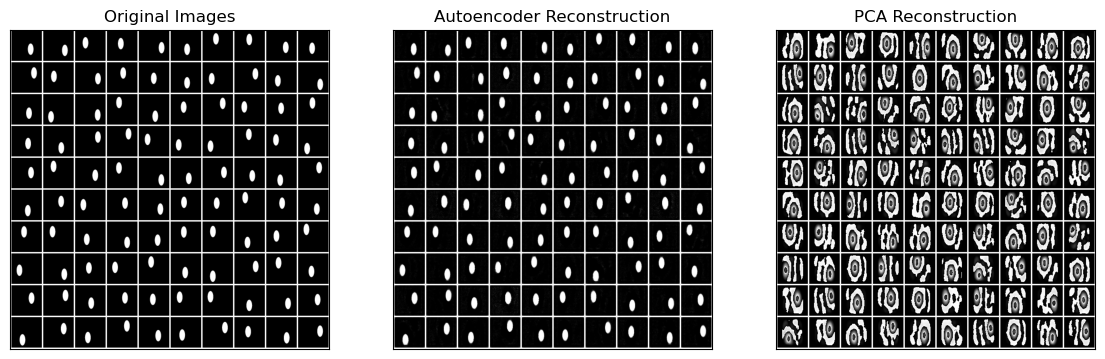

In [17]:
# Reconstructing with the auto encoder
with torch.no_grad():
    y = convAE16.forward(test_tensor)

# Reconstruct with PCA
mean = pca.mean_
centered_flat = test.reshape(100, 64 * 64) - mean
PCS = pca.components_[:latent_dim]
pca_reconstruction = (PCS @ centered_flat.T).T @ PCS + mean
pca_reconstruction_t = torch.from_numpy(
        pca_reconstruction.reshape(100, 64, 64)
    ).unsqueeze(1)

grid_ae = vutils.make_grid(y, nrow = 10, pad_value = 1, padding=3)
grid_t =  vutils.make_grid(test_tensor, nrow = 10, pad_value = 1, padding=3)
grid_pca = vutils.make_grid(
    pca_reconstruction_t,
    nrow = 10, 
    pad_value = 1, 
    padding=3
    )

show([grid_t, grid_ae, grid_pca], titles = ["Original Images", "Autoencoder Reconstruction", "PCA Reconstruction"])

Now the autoencoder does a lot better, but PCA still struggles heavily. 

#### C. PCA in Latent Space

*Note:* I'm running PCA on the embeddings from the training data, since the question did not specify the test dataset.

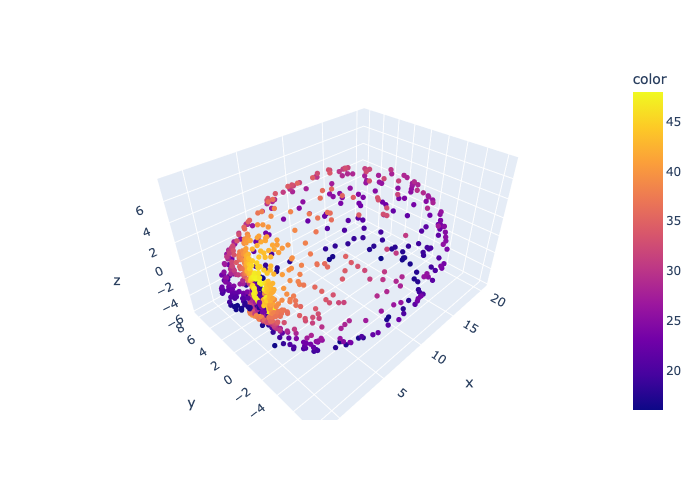

In [18]:
latent_embeddings = convAE16.encoder(torch.from_numpy(data).type(torch.float32).to(device).unsqueeze(1)).squeeze().detach().cpu().numpy()
pca_latent = PCA(n_components=latent_dim)
pca_latent.fit(latent_embeddings)

# Project to 3D
top_3_comp = pca_latent.components_[:3]
proj_3 = (top_3_comp @ latent_embeddings.T).T

fig = px.scatter_3d(
    x = proj_3[:, 0],
    y = proj_3[:, 1],
    z = proj_3[:, 2],
    color=rows
    )
fig.update_traces(marker=dict(size=3))  # smaller dots
fig.update_layout(scene_camera=dict(eye=dict(x=-1.25, y=-1.25, z=1.25)))

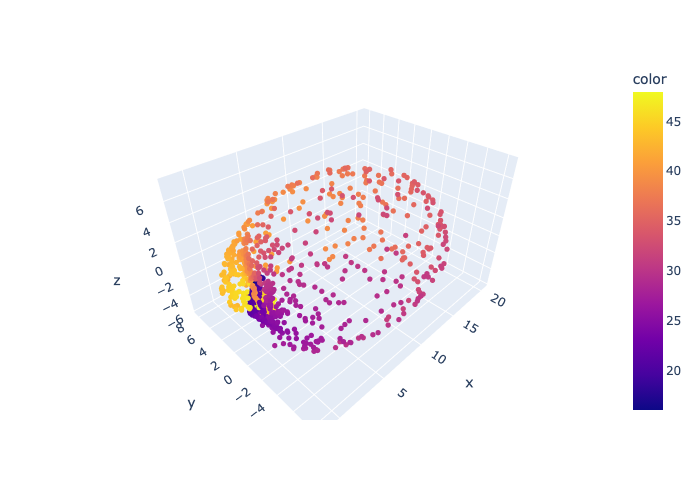

In [19]:
latent_embeddings = convAE16.encoder(torch.from_numpy(data).type(torch.float32).to(device).unsqueeze(1)).squeeze().detach().cpu().numpy()
pca_latent = PCA(n_components=latent_dim)
pca_latent.fit(latent_embeddings)

# Project to 3D
top_3_comp = pca_latent.components_[:3]
proj_3 = (top_3_comp @ latent_embeddings.T).T

fig = px.scatter_3d(
    x = proj_3[:, 0],
    y = proj_3[:, 1],
    z = proj_3[:, 2],
    color=cols
    )
fig.update_traces(marker=dict(size=3))  # smaller dots
fig.update_layout(scene_camera=dict(eye=dict(x=-1.25, y=-1.25, z=1.25)))

That looks incredibaly cool. This shape, however, is certainly not flat.

#### D. Immersion Test


In [20]:
# Make a function that computes the rank of the Jacobian at any given input

In [21]:
from torch.func import jacfwd

## NOTE: I computed J_2 and J_16 on the gpu clusters, since they took a LONG time. Here is the code I used to compute them:
"""
imgs = torch.Tensor(test).to(device).unsqueeze(1).to(device)
print(imgs.shape)
latents_2 = convAE2.encoder(imgs)
latents_big = convAE16.encoder(imgs)

J_2 = torch.autograd.functional.jacobian(convAE2.decoder, latents_2)

print(J_2)

torch.save(J_2, "J_2")


J_16 = torch.autograd.functional.jacobian(convAE16.decoder, latents_big)

print(J_16)

torch.save(J_16, "J_16")
"""

test_embeddings_2 = convAE2.encoder(test_tensor.to(device))
test_embeddings_16 = convAE16.encoder(test_tensor.to(device))



J_2 = torch.vmap(jacfwd(convAE2.decoder))(test_embeddings_2[:,np.newaxis,:,:,:]).squeeze()
J_16 = torch.vmap(jacfwd(convAE16.decoder))(test_embeddings_16[:,np.newaxis,:,:,:]).squeeze()

# J_2 = torch.load("J_2", map_location="mps")
# J_16 = torch.load("J_16", map_location="mps")




rank_2 = torch.linalg.matrix_rank(J_2.moveaxis(-1, 1).flatten(start_dim=2))
rank_2_a = rank_2.cpu().numpy()

rank_16 = torch.linalg.matrix_rank(J_16.moveaxis(-1, 1).flatten(start_dim=2))
rank_16_a = rank_16.cpu().numpy()

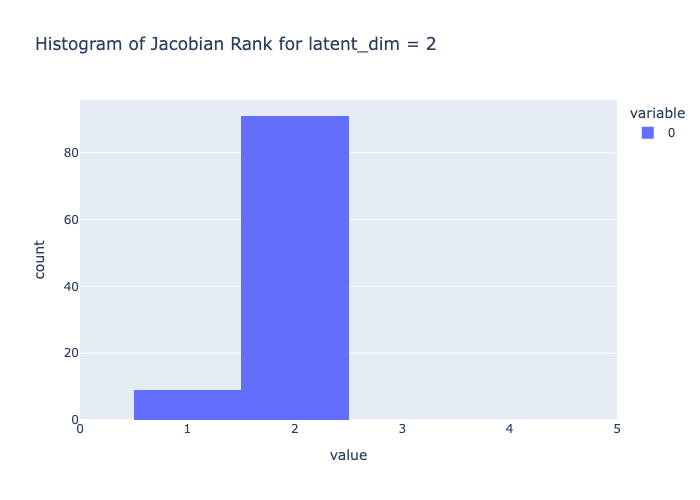

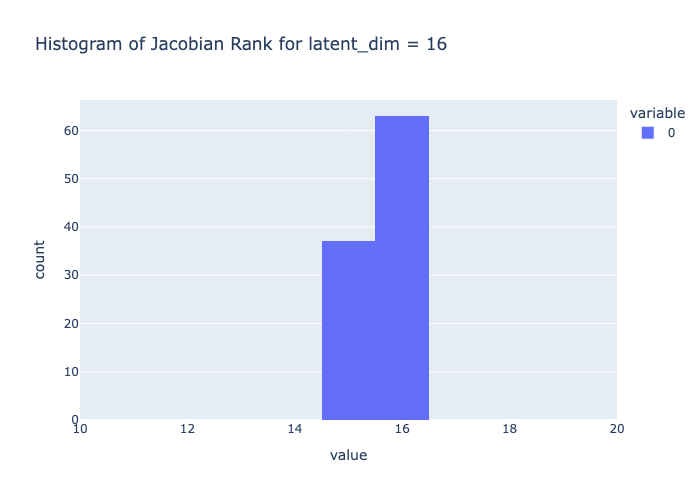

In [22]:
fig = px.histogram(rank_2_a, title="Histogram of Jacobian Rank for latent_dim = 2")
fig.update_xaxes(range=[0, 5])
fig.show()

fig = px.histogram(rank_16_a, title="Histogram of Jacobian Rank for latent_dim = 16")
fig.update_xaxes(range=[10, 20])
fig.show()

Both of these autoencoders are less than full rank. The autoencoder with the two-dimensional latent space is not full rank everwhere, but it is close, 6/100 inputs are rank 1 in the output. The autoencoder with the 16-dimensional latent space is worse, being full rank only at about half of the inputs. Both these autoencoders fail to be immersions. I'm not sure how to interpret these in light of the data having an intrinsic dimensionality of two. Maybe this is an artifact of sub-optimal training.


### Part 4

In [23]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import torch
from torchvision import transforms
from PIL import Image
from sklearn.manifold import Isomap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

teapots = torch.load("teapot.pth")[100:1100]


#### 2.A IsoMap

Based on the visualazations of a few datapoints, it seems like the images of the teapot only change in orientation. I believe that 3D orientation has a geometry similar to a high dimensional tourus. The teapot can be pointed in any direction in $\mathbb{R^3}$. The set of possible unit direction vectors is homeomorphic to $S^2$. The extra dimension comes in through rotation of the object around the unit direction vector. But as the object completes a full rotation around its direction vector, it ends up in the same spot. Therefore I believe the manifold must have some kind of tourus-like geometry.

I guess IsoMap counld make a decent embedding in 4 dimensions, but I don't think the embedding would be properly isomorphic, since the geometry of possible orientations seems inherently curved.

#### 2.B Eigen Analysis

No IsoMap fit found, computing from scratch
Loaded eigenvalues
Number of non-negative eigenvalues: 779
Number of negative eigenvalues: 221


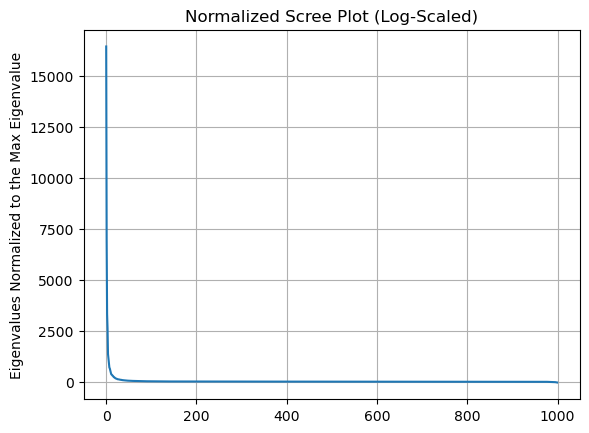

In [24]:
import joblib

N = 1_000

flat_teapots = teapots.reshape(N, 3 * 64 * 64)

try:
    embedding = joblib.load("teapot_iso.joblib")
    print("Loaded IsoMap embedding")
except:
    print("No IsoMap fit found, computing from scratch")
    embedding = Isomap(
        n_components=3,
        n_neighbors=5,
        path_method='D',
        n_jobs=-1,
    )
    embedding.fit(X = flat_teapots)


try:
    normalized_svs = torch.load("teapot_eigenvalues.pth", map_location="mps", weights_only=False)
    print("Loaded eigenvalues")
except:
    ## computing the Gram Matrix 
    print("No eigenvalues found, computing from scratch")
    D = embedding.dist_matrix_
    H = np.identity(N) - 1/N * np.ones((N,N))

    B = -1/2 * H @ D @ H

    # Eigen Analysis
    singular_values, vects = np.linalg.eig(B)
    singular_values = np.sort(singular_values)[::-1]
    torch.save(singular_values, "teapot_eigenvalues.pth")


plt.plot(singular_values)
plt.title("Normalized Scree Plot (Log-Scaled)")
plt.ylabel("Eigenvalues Normalized to the Max Eigenvalue")
plt.grid()
#plt.yscale("log")

Negative = np.sum((singular_values < 0))
print(f"Number of non-negative eigenvalues: {len(singular_values) - Negative}")
print(f"Number of negative eigenvalues: {Negative}")

I don't think this data manifold is flat either, since almost half of its eigenvalues are flat. Because of how curved this manifold is, I'm not sure how well IsoMap will do embedding it into a lower dimensional space.


#### 2.D 3D Isomap Scatter


In [25]:
try:
    transformed_teapots = torch.load("teapot_transformed.pth", map_location=device, weights_only=False)
    print("Loaded transformed teapots")
except:
    print("No transformed teapots found, computing from scratch")

    transformed_teapots = embedding.fit_transform(X= flat_teapots)
    torch.save(transformed_teapots, "teapot_transformed.pth")

Loaded transformed teapots


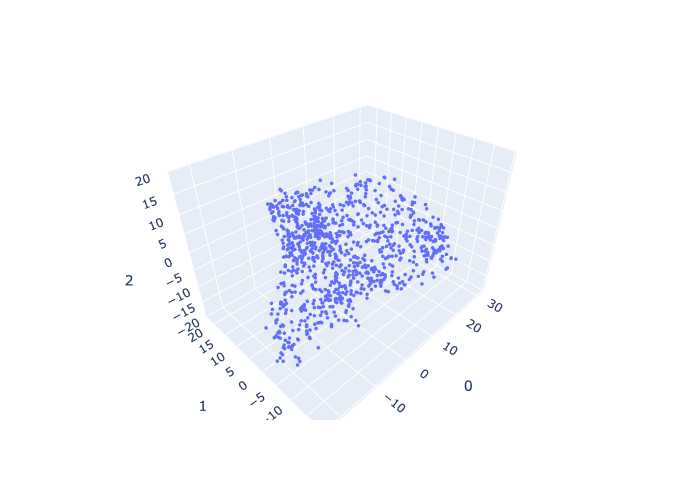

In [26]:
df = pd.DataFrame(transformed_teapots, columns=["X", "Y", "Z"])
fig = px.scatter_3d(
    transformed_teapots,
    x = 0,
    y = 1,
    z = 2
    )
fig.update_traces(marker=dict(size=2))  # smaller dots
fig.update_layout(scene_camera=dict(eye=dict(x=-1.25, y=-1.25, z=1.25)))

I was right about the curvature, this shape is definitely not flat. This shape is decently full in $\mathbb{R}^3$, meaning it could be a 3-dimensional manifold.

#### 3.A Small Autoencoder


In [27]:
import joblib

N = 1_000
batch_size = 100   # set a batch size that works for you (might just use N)
num_channels = 3   # set this to 1 for ellipse (grayscale) and 3 for teapot (colbor)


X = torch.Tensor(teapots).to(device)

# These are dummy labels needed to create pytorch TensorDataset
y = torch.zeros(N).to(device)

train_data = TensorDataset(X, y)
train_loader = DataLoader(train_data, batch_size = batch_size, shuffle = True)

In [28]:
# print(N)
latent_dim = 4
teapot_AE4 = ConvolutionalAutoencoder(3, latent_dim).to(device)
## open a checkpoint if possible
try:
    teapot_AE4.load_state_dict(torch.load("teapot_AE4.pth", map_location=device))
    print("Loaded checkpoint")
except:
    print("No checkpoint found, training from scratch")
    teapot_AE4 = train(teapot_AE4, train_loader, num_epochs=20)
    torch.save(teapot_AE4.state_dict(), "teapot_AE4.pth")

Loaded checkpoint


In [29]:
# plotting grids
def show(imgs, titles = None): ## from pytroch tutorial
    if not isinstance(imgs, list):
        imgs = [imgs]
    fig, axs = plt.subplots(ncols=len(imgs), squeeze=False, figsize = (14, 7))
    for i, img in enumerate(imgs):
        img = img.detach().cpu()
        img = transforms.functional.to_pil_image(img)
        axs[0, i].imshow(np.asarray(img))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])
        if titles:
            axs[0, i].set_title(titles[i])
# vizualize real data
viz_sample = teapots[:100]
grid_true = vutils.make_grid(viz_sample, nrow = 10, pad_value = 1, padding=3)

# vizualize AE reconstructions
AE_reconstr = teapot_AE4(viz_sample.to(device)).cpu()
grid_ae = vutils.make_grid(AE_reconstr, nrow = 10, pad_value = 1, padding=3)

# Vizualize PCA reconstruction

pca = PCA(n_components=4)
pca.fit(flat_teapots);

torch.Size([100, 3, 64, 64])


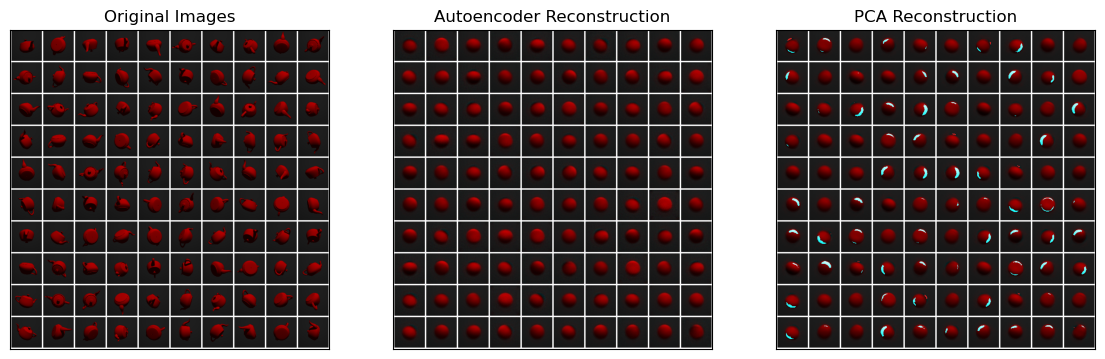

In [30]:
mean = pca.mean_
centered_flat = viz_sample.reshape(100, 3 * 64 * 64).cpu().numpy() - mean
PCS = pca.components_[:latent_dim]
pca_reconstruction = (PCS @ centered_flat.T).T @ PCS + mean
pca_reconstruction_t = torch.from_numpy(
        pca_reconstruction.reshape(100, 3, 64, 64)
    )

print(pca_reconstruction_t.shape)


grid_pca = vutils.make_grid(
    pca_reconstruction_t,
    nrow = 10,
    pad_value = 1,
    padding=3
    )

## show the grids
show([grid_true, grid_ae, grid_pca], titles = ["Original Images", "Autoencoder Reconstruction", "PCA Reconstruction"])

This autoencoder does a terrible job, sometimes worse than PCA. I The autoencoder just learns to create shaded sphere in place of the teapots. Maybe adding more latent dims would help.

#### 3.B Larger Autoencoder

In [31]:
# print(N)
latent_dim = 16
teapot_AE16 = ConvolutionalAutoencoder(3, latent_dim).to(device)
## open a checkpoint if possible
try:
    teapot_AE16.load_state_dict(torch.load("teapot_AE16.pth", map_location=device))
    print("Loaded checkpoint")
except:
    print("No checkpoint found, training from scratch")
    teapot_AE16 = train(teapot_AE16, train_loader, num_epochs=20)
    torch.save(teapot_AE16.state_dict(), "teapot_AE16.pth")

Loaded checkpoint


In [32]:
# plotting grids
def show(imgs, titles = None): ## from pytroch tutorial
    if not isinstance(imgs, list):
        imgs = [imgs]
    fig, axs = plt.subplots(ncols=len(imgs), squeeze=False, figsize = (14, 7))
    for i, img in enumerate(imgs):
        img = img.detach().cpu()
        img = transforms.functional.to_pil_image(img)
        axs[0, i].imshow(np.asarray(img))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])
        if titles:
            axs[0, i].set_title(titles[i])
# vizualize real data
viz_sample = teapots[:100]
grid_true = vutils.make_grid(viz_sample, nrow = 10, pad_value = 1, padding=3)

# vizualize AE reconstructions
AE_reconstr = teapot_AE16(viz_sample.to(device)).cpu()
grid_ae = vutils.make_grid(AE_reconstr, nrow = 10, pad_value = 1, padding=3)

# Vizualize PCA reconstruction

pca = PCA(n_components=latent_dim);
pca.fit(flat_teapots)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",16
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD

torch.Size([100, 3, 64, 64])


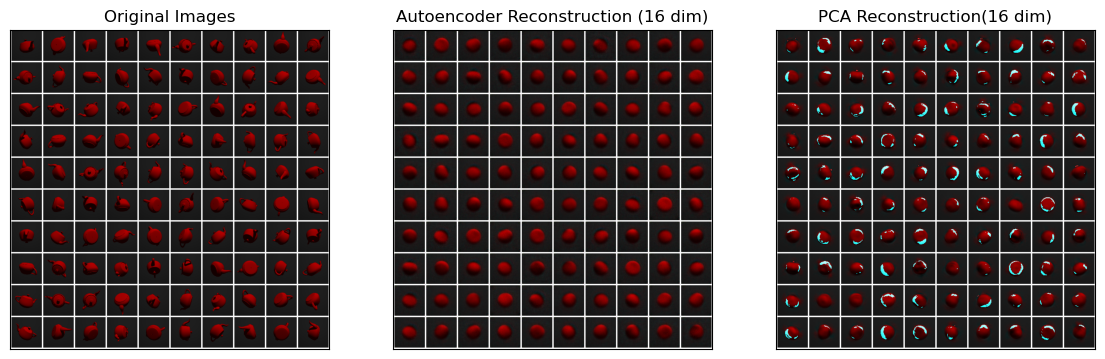

In [33]:
mean = pca.mean_
centered_flat = viz_sample.reshape(100, 3 * 64 * 64).cpu().numpy() - mean
PCS = pca.components_[:latent_dim]
pca_reconstruction = (PCS @ centered_flat.T).T @ PCS + mean
pca_reconstruction_t = torch.from_numpy(
        pca_reconstruction.reshape(100, 3, 64, 64)
    )

print(pca_reconstruction_t.shape)


grid_pca = vutils.make_grid(
    pca_reconstruction_t,
    nrow = 10,
    pad_value = 1,
    padding=3
    )

## show the grids
show([grid_true, grid_ae, grid_pca], titles = ["Original Images", "Autoencoder Reconstruction (16 dim)", "PCA Reconstruction(16 dim)"])

#### 3.C PCA in Latent Space

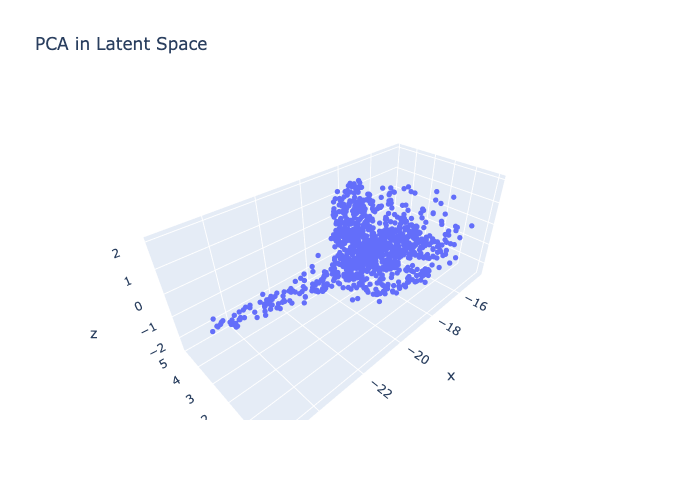

In [34]:
latent_embeddings = teapot_AE16.encoder(teapots[:1000].to(device)).squeeze().detach().cpu().numpy()
pca_latent = PCA(n_components=latent_dim)
pca_latent.fit(latent_embeddings)

# Project to 3D
top_3_comp = pca_latent.components_[:3]
proj_3 = (top_3_comp @ latent_embeddings.T).T

fig = px.scatter_3d(
    x = proj_3[:, 0],
    y = proj_3[:, 1],
    z = proj_3[:, 2],
    title="PCA in Latent Space"
    )
fig.update_traces(marker=dict(size=3))  # smaller dots
fig.update_layout(scene_camera=dict(eye=dict(x=-1.25, y=-1.25, z=1.25)))

I don't know how we could tell if this data lies on a flat manifold in the latent space given our projection into 3d. If it is curved in 4d space, it would of course loose its curvature when projected into 3 dimensions, similar to how a sphere in 3d looks like a disk when projected into 2d.

#### 3.D Immersion Test

In [35]:
latents_4 = teapot_AE4.encoder(viz_sample.to(device))
latents_16 = teapot_AE16.encoder(viz_sample.to(device))

J_tea_4 = torch.vmap(jacfwd(teapot_AE4.decoder))(latents_4[:,np.newaxis,:,:,:]).squeeze()
J_tea_16 = torch.vmap(jacfwd(teapot_AE16.decoder))(latents_16[:,np.newaxis,:,:,:]).squeeze()

rank_4 = torch.linalg.matrix_rank(J_tea_4.moveaxis(-1, 1).flatten(start_dim=2))
rank_16 = torch.linalg.matrix_rank(J_tea_16.moveaxis(-1, 1).flatten(start_dim=2))
rank_4_a = rank_4.cpu().numpy()
rank_16_a = rank_16.cpu().numpy()

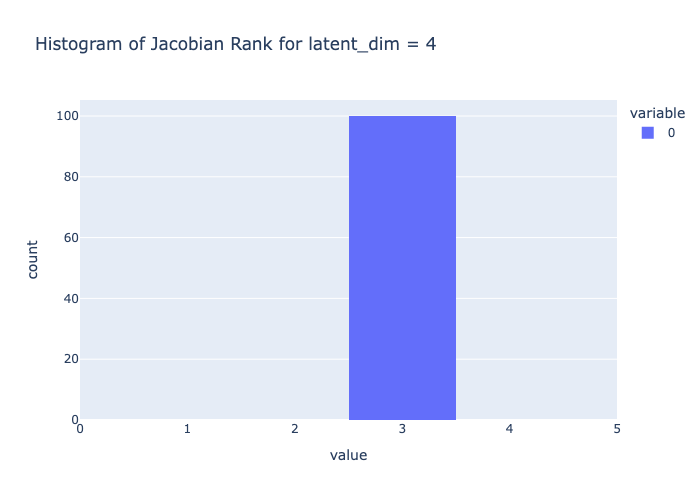

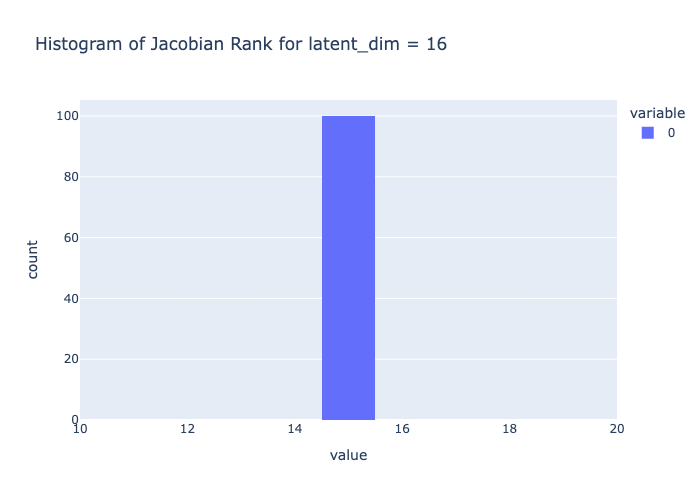

In [36]:
fig = px.histogram(rank_4_a, title="Histogram of Jacobian Rank for latent_dim = 4")
fig.update_xaxes(range=[0, 5])
fig.show()

fig = px.histogram(rank_16_a, title="Histogram of Jacobian Rank for latent_dim = 16")
fig.update_xaxes(range=[10, 20])
fig.show()

Interesting, these histograms indicate that this deocder is not an immersion, since the Jacobian is not full rank. The ranks at all inputs for both decoders are one less than their latent dimension. This might be because of some training issue, but I'm not sure.